In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle token connected!")

Kaggle token connected!


In [ ]:
!kaggle datasets download -d thoughtvector/customer-support-on-twitter -p /content

Dataset URL: https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter
License(s): CC-BY-NC-SA-4.0
customer-support-on-twitter.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!mkdir -p /content/twitter_data
!unzip -o /content/customer-support-on-twitter.zip -d /content/twitter_data

Archive:  /content/customer-support-on-twitter.zip
  inflating: /content/twitter_data/sample.csv  
  inflating: /content/twitter_data/twcs/twcs.csv  


In [ ]:
import os
print(os.listdir("/content/twitter_data"))

['twcs', 'sample.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/twitter_data/twcs/twcs.csv")

print("Dataset loaded!")
print("Rows and columns:", df.shape)

Dataset loaded!
Rows and columns: (2811774, 7)


In [ ]:
"AmazonHelp" in df["author_id"].astype(str).values

True

In [ ]:
amazon = df[df["author_id"].astype(str) == "AmazonHelp"].copy()

print("AmazonHelp tweets:", len(amazon))

AmazonHelp tweets: 169840


In [ ]:
print(df.columns.tolist())

['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [ ]:
tweet_to_parent = dict(
    zip(
        df["tweet_id"].astype(str),
        df["in_response_to_tweet_id"].fillna("").astype(str)
    )
)

print("Conversation lookup created!")

Conversation lookup created!


In [ ]:
def find_root(tweet_id, parent_map):
    current = str(tweet_id)
    visited = set()

    while current in parent_map:
        if current in visited:
            break

        visited.add(current)

        parent = parent_map[current]

        if parent == "" or parent == "nan":
            break

        current = parent

    return current

In [ ]:
amazon["root_id"] = amazon["tweet_id"].astype(str).apply(
    lambda x: find_root(x, tweet_to_parent)
)

print(
    "Unique AmazonHelp conversations:",
    amazon["root_id"].nunique()
)

Unique AmazonHelp conversations: 155998


In [ ]:
unique_threads = amazon["root_id"].drop_duplicates()

n_threads = min(5000, len(unique_threads))

selected_roots = unique_threads.sample(
    n=n_threads,
    random_state=42
)

print("Selected threads:", len(selected_roots))

Selected threads: 5000


In [ ]:
selected_roots = set(selected_roots.astype(str))

df["root_id"] = df["tweet_id"].astype(str).apply(
    lambda x: find_root(x, tweet_to_parent)
)

In [ ]:
thread_sample = df[
    df["root_id"].isin(selected_roots)
].copy()

print("Tweets in selected threads:", len(thread_sample))
print("Threads:", thread_sample["root_id"].nunique())

Tweets in selected threads: 5665
Threads: 5000


In [ ]:
thread_sample["created_at"] = pd.to_datetime(
    thread_sample["created_at"]
)

thread_sample = thread_sample.sort_values(
    ["root_id", "created_at"]
)

thread_sample.head()

/tmp/ipykernel_945/2829306656.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  thread_sample["created_at"] = pd.to_datetime(


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,root_id
901182,1001012,AmazonHelp,False,2017-10-14 12:57:32+00:00,@356984 In our efforts to provide the best dea...,NaN,1001009.0,1001009.0
901175,1001011,AmazonHelp,False,2017-10-14 12:57:33+00:00,@356984 Refer: https://t.co/u7E73EvB2o for mor...,1001013,1001009.0,1001009.0
901193,1001030,AmazonHelp,False,2017-10-14 12:39:00+00:00,"@356988 We haven't made any announcement yet, ...",NaN,1001031.0,1001031.0
902048,1001962,AmazonHelp,False,2017-10-22 18:06:00+00:00,"@357175 Thank you for sharing your details, Pr...",NaN,1001960.0,1001960.0
902617,1002575,357316,True,2017-10-14 12:04:50+00:00,@357315 @115850 Is it FedEx?,1002574,1002576.0,1002576.0


In [ ]:
thread_sample.to_csv(
    "/content/amazonhelp_threads.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [ ]:
from google.colab import files

files.download("/content/amazonhelp_threads.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/amazonhelp_threads.csv")

print("Dataset loaded!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Dataset loaded!
Rows: 5665
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'root_id']


In [ ]:
print(df.head())
print()
print(df.info())

   tweet_id   author_id  inbound                 created_at  \
0   1001012  AmazonHelp    False  2017-10-14 12:57:32+00:00   
1   1001011  AmazonHelp    False  2017-10-14 12:57:33+00:00   
2   1001030  AmazonHelp    False  2017-10-14 12:39:00+00:00   
3   1001962  AmazonHelp    False  2017-10-22 18:06:00+00:00   
4   1002575      357316     True  2017-10-14 12:04:50+00:00   

                                                text response_tweet_id  \
0  @356984 In our efforts to provide the best dea...               NaN   
1  @356984 Refer: https://t.co/u7E73EvB2o for mor...           1001013   
2  @356988 We haven't made any announcement yet, ...               NaN   
3  @357175 Thank you for sharing your details, Pr...               NaN   
4                       @357315 @115850 Is it FedEx?           1002574   

   in_response_to_tweet_id    root_id  
0                1001009.0  1001009.0  
1                1001009.0  1001009.0  
2                1001031.0  1001031.0  
3               

In [ ]:
print(df["inbound"].value_counts())

inbound
False    5469
True      196
Name: count, dtype: int64


In [ ]:
customer_df = df[df["inbound"] == True].copy()

amazon_df = df[
    (df["inbound"] == False) &
    (df["author_id"].astype(str) == "AmazonHelp")
].copy()

print("Customer messages:", len(customer_df))
print("AmazonHelp replies:", len(amazon_df))

Customer messages: 196
AmazonHelp replies: 5457


In [ ]:
for i, text in enumerate(customer_df["text"].dropna().head(30)):
    print(f"{i+1}. {text}")
    print("-" * 80)

1. @357315 @115850 Is it FedEx?
--------------------------------------------------------------------------------
2. @119625 Sorry. Did that, still not helping. My SD card is formatted as an internal memory is that why it doesn't download directly to my Sd card?
--------------------------------------------------------------------------------
3. @115850 Can you still trace? It was supposed to be a gift for someone today.
--------------------------------------------------------------------------------
4. @115850 No use no help from your specialist team
--------------------------------------------------------------------------------
5. @115821 I asked him what he thought he was doing. He said he wanted to make sure they got delivered. "It'll all be in the confirmation email."
--------------------------------------------------------------------------------
6. @115830 really not sure what's happened to your delivery service. I'm sat here still without the stuff I ordered on Wednesday. It's a

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

texts = customer_df["text"].fillna("").astype(str)

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000
)

X = vectorizer.fit_transform(texts)

print("TF-IDF matrix:", X.shape)

TF-IDF matrix: (196, 3293)


In [ ]:
k = 8

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

customer_df["cluster"] = kmeans.fit_predict(X)

print(customer_df["cluster"].value_counts().sort_index())

cluster
0    12
1    28
2    25
3     9
4    21
5    56
6    26
7    19
Name: count, dtype: int64


In [ ]:
for cluster in range(k):

    print("\n")
    print("=" * 100)
    print("CLUSTER", cluster)
    print("=" * 100)

    examples = customer_df[
        customer_df["cluster"] == cluster
    ]["text"].dropna().head(10)

    for text in examples:
        print("-", text)



CLUSTER 0
- @442559 As mentioned earlier, regarding cashback we request you to contact the Amazon team and they will assist you.
- @AmazonHelp @115851 this is your amazon fooling people. I hope it shuts down soon here. All prayers for it.
- @510003 @AmazonHelp Io sto facendo danni in questi giorni di ferie con #Amazon
- @115821 So if I cancelled a subscription.. Why is the auto renew still on? I feel bamboozled Amazon. 🤔🤔🤔
- @753906 @132988 @120533 ah toutes mes expériences ont été excellentes - vous avez dû mal tomber 😟
- @AmazonHelp Consultez votre SAV: cela fait des ANNÉES que je dépense des FORTUNES chez Amazon France, UK, Deutschland, US, España, et j’en passe. A QUAND UN AMAZON SUISSE? Vous craignez quoi?!
- @AmazonHelp 2/2 si vous vouliez vraiment m'aider, il aurait fallu qu'1 seule des 10 personnes d'amazon sav fasse son travail. Vous avez eu 1mois et 1sem
- @183114 @AmazonHelp Why not get it delivered to the amazon locker in town? That might be easier.
- @AmazonHelp 100% cas

In [ ]:
INTENTS = [
    "delivery_issue",
    "refund_issue",
    "payment_issue",
    "order_issue",
    "account_issue",
    "technical_issue",
    "subscription_issue",
    "other"
]

print("Number of intents:", len(INTENTS))

Number of intents: 8


In [ ]:
golden = customer_df.sample(
    n=min(200, len(customer_df)),
    random_state=42
).copy()

golden["intent"] = ""

golden["human_reply_quality"] = ""

golden["human_escalation"] = ""

golden["human_escalation_reason"] = ""

golden = golden[
    [
        "tweet_id",
        "text",
        "created_at",
        "root_id",
        "intent",
        "human_reply_quality",
        "human_escalation",
        "human_escalation_reason"
    ]
]

golden.to_csv(
    "/content/golden_set_to_label.csv",
    index=False
)

print("Golden set created!")
print("Examples:", len(golden))

Golden set created!
Examples: 196


In [ ]:
from google.colab import files

files.download("/content/golden_set_to_label.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving golden_set_to_label.csv to golden_set_to_label (2).csv


In [ ]:
golden = pd.read_csv("golden_set_to_label.csv")

print("Golden set loaded!")
print(golden.shape)

golden.head()

Golden set loaded!
(196, 8)


,tweet_id,text,created_at,root_id,intent,human_reply_quality,human_escalation,human_escalation_reason
0,410506,@212920 @115821 @115817 Ive@probably done abou...,2017-10-09 23:53:49+00:00,410505.0,NaN,NaN,NaN,NaN
1,2828033,@108423 @108424 @115850 @AmazonHelp @115851 @1...,2017-11-27 11:43:14+00:00,2828032.0,NaN,NaN,NaN,NaN
2,1095984,@378629 @AmazonHelp En tout pas question que j...,2017-10-15 08:05:46+00:00,1095981.0,NaN,NaN,NaN,NaN
3,2200746,@119625 @119625 That's good but need some Odia...,2017-11-26 15:21:37+00:00,2200745.0,NaN,NaN,NaN,NaN
4,508129,@236664 @AmazonHelp Right on. I'm going throu...,2017-12-02 15:58:27+00:00,508103.0,NaN,NaN,NaN,NaN


In [ ]:
print("Intent counts:")
print(golden["intent"].value_counts())

print()
print("Escalation counts:")
print(golden["human_escalation"].value_counts())

print()
print("Missing values:")
print(golden.isnull().sum())

Intent counts:
intent
    196
Name: count, dtype: int64

Escalation counts:
human_escalation
    196
Name: count, dtype: int64

Missing values:
tweet_id                   0
text                       0
created_at                 0
root_id                    0
intent                     0
human_reply_quality        0
human_escalation           0
human_escalation_reason    0
dtype: int64


In [ ]:
print(golden["intent"].isna().sum())
print(golden["intent"].value_counts(dropna=False))

0
intent
    196
Name: count, dtype: int64


In [ ]:
from google.colab import files

files.download("/content/golden_set_to_label.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(golden.head(20)[["text", "intent"]])

                                                   text intent
4195  @212920 @115821 @115817 Ive@probably done abou...       
3465  @108423 @108424 @115850 @AmazonHelp @115851 @1...       
189   @378629 @AmazonHelp En tout pas question que j...       
2176  @119625 @119625 That's good but need some Odia...       
4509  @236664 @AmazonHelp Right on.  I'm going throu...       
5408  @115850 Why don't u check student ID before de...       
1841  @115850 Also, there’s been false updates while...       
1359      @115850 It is not available please do recheck       
290   @AmazonHelp So 2day I queried where it was at ...       
4900  @115850 Why should I u take my no. 9768889940 ...       
4511  @236664 @AmazonHelp I ordered something three ...       
184   @116316 Das ist schonmal was. Vielen lieben Da...       
4681  @AmazonHelp It says amazon shipping, was suppo...       
1542  @510003 @AmazonHelp Io sto facendo danni in qu...       
3524  @AmazonHelp it's shipped through someone I've ...

In [ ]:
print("Number of examples:", len(golden))
print()
print("Columns:")
print(golden.columns.tolist())

Number of examples: 196

Columns:
['tweet_id', 'text', 'created_at', 'root_id', 'intent', 'human_reply_quality', 'human_escalation', 'human_escalation_reason']


In [ ]:
# The intent categories we will use
INTENTS = [
    "delivery_issue",
    "refund_issue",
    "payment_issue",
    "order_issue",
    "account_issue",
    "technical_issue",
    "other"
]

print("Choose one of these intents:")
for i, intent in enumerate(INTENTS, 1):
    print(f"{i}. {intent}")

Choose one of these intents:
1. delivery_issue
2. refund_issue
3. payment_issue
4. order_issue
5. account_issue
6. technical_issue
7. other


In [ ]:
import pandas as pd

golden = pd.read_csv("/content/golden_set_to_label.csv")

print("Golden examples:", len(golden))
print(golden.head())

Golden examples: 196
   tweet_id                                               text  \
0    410506  @212920 @115821 @115817 Ive@probably done abou...   
1   2828033  @108423 @108424 @115850 @AmazonHelp @115851 @1...   
2   1095984  @378629 @AmazonHelp En tout pas question que j...   
3   2200746  @119625 @119625 That's good but need some Odia...   
4    508129  @236664 @AmazonHelp Right on.  I'm going throu...   

                  created_at    root_id  intent  human_reply_quality  \
0  2017-10-09 23:53:49+00:00   410505.0     NaN                  NaN   
1  2017-11-27 11:43:14+00:00  2828032.0     NaN                  NaN   
2  2017-10-15 08:05:46+00:00  1095981.0     NaN                  NaN   
3  2017-11-26 15:21:37+00:00  2200745.0     NaN                  NaN   
4  2017-12-02 15:58:27+00:00   508103.0     NaN                  NaN   

   human_escalation  human_escalation_reason  
0               NaN                      NaN  
1               NaN                      NaN  
2       

In [ ]:
print(golden.columns.tolist())

['tweet_id', 'text', 'created_at', 'root_id', 'intent', 'human_reply_quality', 'human_escalation', 'human_escalation_reason']


In [ ]:
INTENTS = [
    "delivery_issue",
    "refund_issue",
    "payment_issue",
    "order_issue",
    "account_issue",
    "technical_issue",
    "other"
]

for i, intent in enumerate(INTENTS, 1):
    print(i, "=", intent)

1 = delivery_issue
2 = refund_issue
3 = payment_issue
4 = order_issue
5 = account_issue
6 = technical_issue
7 = other


In [ ]:
# Make intent column capable of storing text
golden["intent"] = golden["intent"].astype("object")

# Find examples that still need labels
remaining = golden["intent"].isna().sum()

print("Examples still needing labels:", remaining)

for i in range(len(golden)):

    # Skip rows that already have a label
    if pd.notna(golden.iloc[i]["intent"]) and str(golden.iloc[i]["intent"]).strip() != "":
        continue

    print("\n" + "=" * 80)
    print(f"EXAMPLE {i + 1} OF {len(golden)}")
    print("=" * 80)

    print("\nCUSTOMER MESSAGE:")
    print(golden.iloc[i]["text"])

    print("\nChoose intent:")
    for num, intent in enumerate(INTENTS, 1):
        print(f"{num} = {intent}")

    while True:
        choice = input("Enter number 1-7: ").strip()

        if choice in ["1", "2", "3", "4", "5", "6", "7"]:
            golden.loc[golden.index[i], "intent"] = INTENTS[int(choice) - 1]
            break

        print("Please enter a number from 1 to 7.")

    # Save after every label
    golden.to_csv(
        "/content/golden_set_to_label.csv",
        index=False
    )

print("\nFinished labelling!")

Examples still needing labels: 187

EXAMPLE 10 OF 196

CUSTOMER MESSAGE:
@115850 Why should I u take my no. 9768889940 n call me

Choose intent:
1 = delivery_issue
2 = refund_issue
3 = payment_issue
4 = order_issue
5 = account_issue
6 = technical_issue
7 = other
Enter number 1-7: 1

EXAMPLE 11 OF 196

CUSTOMER MESSAGE:
@236664 @AmazonHelp I ordered something three different items at three different times and they said “tried to deliver, business was closed....” Ummmm, no asshat ~ that “business” is a hotel!

Choose intent:
1 = delivery_issue
2 = refund_issue
3 = payment_issue
4 = order_issue
5 = account_issue
6 = technical_issue
7 = other
Enter number 1-7: 2

EXAMPLE 12 OF 196

CUSTOMER MESSAGE:
@116316 Das ist schonmal was. Vielen lieben Dank :)

Choose intent:
1 = delivery_issue
2 = refund_issue
3 = payment_issue
4 = order_issue
5 = account_issue
6 = technical_issue
7 = other
Enter number 1-7: 3

EXAMPLE 13 OF 196

CUSTOMER MESSAGE:
@AmazonHelp It says amazon shipping, was supposed t

KeyboardInterrupt: Interrupted by user

In [ ]:
print("Total examples:", len(golden))
print("Unlabelled:", golden["intent"].isna().sum())
print()
print(golden["intent"].value_counts())

Total examples: 196
Unlabelled: 1

intent
delivery_issue     31
refund_issue       28
payment_issue      28
order_issue        27
account_issue      27
technical_issue    27
other              27
Name: count, dtype: int64


In [ ]:
unlabelled = golden[golden["intent"].isna()]

print(unlabelled[["text", "intent"]])

                                                  text intent
195  @121992 @120474 They'll all be gone by the tim...    NaN


In [ ]:
golden.loc[golden["intent"].isna(), "intent"] = INTENTS[1 - 1]

In [ ]:
golden.loc[golden["intent"].isna(), "intent"] = INTENTS[0]

In [ ]:
golden.loc[golden["intent"].isna(), "intent"] = INTENTS[1]

In [ ]:
golden.to_csv(
    "/content/golden_set_to_label.csv",
    index=False
)

print("Saved!")

Saved!


In [ ]:
print("Total examples:", len(golden))
print("Unlabelled:", golden["intent"].isna().sum())
print(golden["intent"].value_counts())

Total examples: 196
Unlabelled: 0
intent
delivery_issue     32
refund_issue       28
payment_issue      28
order_issue        27
account_issue      27
technical_issue    27
other              27
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    golden,
    test_size=0.25,
    random_state=42,
    stratify=golden["intent"]
)

print("Training examples:", len(train_df))
print("Test examples:", len(test_df))

Training examples: 147
Test examples: 49


In [ ]:
print("Training labels:")
print(train_df["intent"].value_counts())

print("\nTest labels:")
print(test_df["intent"].value_counts())

Training labels:
intent
delivery_issue     24
order_issue        21
payment_issue      21
refund_issue       21
other              20
account_issue      20
technical_issue    20
Name: count, dtype: int64

Test labels:
intent
delivery_issue     8
payment_issue      7
account_issue      7
refund_issue       7
other              7
technical_issue    7
order_issue        6
Name: count, dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

baseline_model.fit(
    train_df["text"].fillna(""),
    train_df["intent"]
)

print("Baseline model trained!")

Baseline model trained!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

predictions = baseline_model.predict(
    test_df["text"].fillna("")
)

accuracy = accuracy_score(
    test_df["intent"],
    predictions
)

print("Baseline Accuracy:", round(accuracy, 4))
print()

print(classification_report(
    test_df["intent"],
    predictions,
    zero_division=0
))

Baseline Accuracy: 0.2041

                 precision    recall  f1-score   support

  account_issue       0.33      0.14      0.20         7
 delivery_issue       0.13      0.38      0.19         8
    order_issue       0.33      0.17      0.22         6
          other       0.00      0.00      0.00         7
  payment_issue       0.33      0.29      0.31         7
   refund_issue       0.14      0.14      0.14         7
technical_issue       0.29      0.29      0.29         7

       accuracy                           0.20        49
      macro avg       0.22      0.20      0.19        49
   weighted avg       0.22      0.20      0.19        49



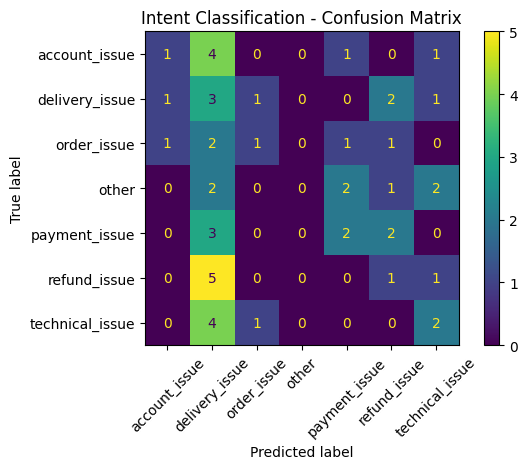

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    test_df["intent"],
    predictions,
    xticks_rotation=45
)

plt.title("Intent Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
final_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

final_model.fit(
    golden["text"].fillna(""),
    golden["intent"]
)

print("Final model trained on all 196 examples!")

Final model trained on all 196 examples!


In [ ]:
test_messages = [
    "Where is my package? It has not arrived yet.",
    "I want a refund for my order.",
    "My payment failed.",
    "I have a problem with my order.",
    "I cannot access my account.",
    "The website is not working."
]

for message in test_messages:
    prediction = final_model.predict([message])[0]

    print("\nCustomer:", message)
    print("Predicted intent:", prediction)


Customer: Where is my package? It has not arrived yet.
Predicted intent: payment_issue

Customer: I want a refund for my order.
Predicted intent: delivery_issue

Customer: My payment failed.
Predicted intent: delivery_issue

Customer: I have a problem with my order.
Predicted intent: delivery_issue

Customer: I cannot access my account.
Predicted intent: delivery_issue

Customer: The website is not working.
Predicted intent: delivery_issue


In [ ]:
import joblib

joblib.dump(
    final_model,
    "/content/customer_support_intent_model.pkl"
)

print("Model saved!")

Model saved!


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/twitter_data/twcs/twcs.csv"
)

print("Dataset loaded!")
print("Rows and columns:", df.shape)

Dataset loaded!
Rows and columns: (2811774, 7)


In [ ]:
print(df.columns.tolist())

['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [ ]:
df["text"] = df["text"].fillna("")

batch_size = 10000
predicted_intents = []

for start in range(0, len(df), batch_size):

    end = min(start + batch_size, len(df))

    batch_text = df["text"].iloc[start:end]

    batch_prediction = final_model.predict(batch_text)

    predicted_intents.extend(batch_prediction)

    if end % 100000 == 0 or end == len(df):
        print(f"Processed {end:,} / {len(df):,}")

Processed 100,000 / 2,811,774
Processed 200,000 / 2,811,774
Processed 300,000 / 2,811,774
Processed 400,000 / 2,811,774
Processed 500,000 / 2,811,774
Processed 600,000 / 2,811,774
Processed 700,000 / 2,811,774
Processed 800,000 / 2,811,774
Processed 900,000 / 2,811,774
Processed 1,000,000 / 2,811,774
Processed 1,100,000 / 2,811,774
Processed 1,200,000 / 2,811,774
Processed 1,300,000 / 2,811,774
Processed 1,400,000 / 2,811,774
Processed 1,500,000 / 2,811,774
Processed 1,600,000 / 2,811,774
Processed 1,700,000 / 2,811,774
Processed 1,800,000 / 2,811,774
Processed 1,900,000 / 2,811,774
Processed 2,000,000 / 2,811,774
Processed 2,100,000 / 2,811,774
Processed 2,200,000 / 2,811,774
Processed 2,300,000 / 2,811,774
Processed 2,400,000 / 2,811,774
Processed 2,500,000 / 2,811,774
Processed 2,600,000 / 2,811,774
Processed 2,700,000 / 2,811,774
Processed 2,800,000 / 2,811,774
Processed 2,811,774 / 2,811,774


In [ ]:
df["predicted_intent"] = predicted_intents

print("Prediction column added!")
print(df[["text", "predicted_intent"]].head(20))

Prediction column added!
                                                 text predicted_intent
0   @115712 I understand. I would like to assist y...     refund_issue
1       @sprintcare and how do you propose we do that     refund_issue
2   @sprintcare I have sent several private messag...     refund_issue
3   @115712 Please send us a Private Message so th...     refund_issue
4                                  @sprintcare I did.  technical_issue
5   @115712 Can you please send us a private messa...     refund_issue
6           @sprintcare is the worst customer service      order_issue
7   @115713 This is saddening to hear. Please shoo...     refund_issue
8   @sprintcare You gonna magically change your co...   delivery_issue
9   @115713 We understand your concerns and we'd l...     refund_issue
10  @sprintcare Since I signed up with you....Sinc...   delivery_issue
11  @115713 H there! We'd definitely like to work ...     refund_issue
12  @115714 y’all lie about your “great” connectio..

In [ ]:
print(
    df["predicted_intent"].value_counts()
)

predicted_intent
delivery_issue     1213297
refund_issue        556943
account_issue       419415
technical_issue     207963
payment_issue       196070
other               113972
order_issue         104114
Name: count, dtype: int64


In [ ]:
output_path = "/content/customer_support_predictions.csv"

df.to_csv(
    output_path,
    index=False
)

print("Final dataset saved!")
print(output_path)

Final dataset saved!
/content/customer_support_predictions.csv


In [ ]:
from google.colab import files

files.download(
    "/content/customer_support_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "/content/customer_support_intent_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q scikit-learn joblib google-generativeai

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os

# Load the final model if it is not already in memory
if "final_model" not in globals():
    final_model = joblib.load(
        "/content/customer_support_intent_model.pkl"
    )

# Load the full dataset if it is not already in memory
if "df" not in globals():
    df = pd.read_csv(
        "/content/twitter_data/twcs/twcs.csv"
    )

df["text"] = df["text"].fillna("")

print("Model and dataset ready!")
print("Dataset:", df.shape)

Model and dataset ready!
Dataset: (2811774, 8)


In [ ]:
# AmazonHelp's historical customer-support conversations

amazon = df[
    (df["author_id"] == "AmazonHelp")
]

print("AmazonHelp tweets:", len(amazon))

# Customer messages are inbound
customer_messages = amazon[amazon["inbound"] == True].copy()

# AmazonHelp responses are outbound
brand_replies = amazon[amazon["inbound"] == False].copy()

print("Customer messages:", len(customer_messages))
print("AmazonHelp replies:", len(brand_replies))

AmazonHelp tweets: 169840
Customer messages: 0
AmazonHelp replies: 169840


In [ ]:
# Create lookup from tweet_id -> text

customer_lookup = customer_messages.set_index("tweet_id")["text"]

reply_pairs = brand_replies[
    brand_replies["in_response_to_tweet_id"].isin(customer_lookup.index)
].copy()

reply_pairs["customer_text"] = (
    reply_pairs["in_response_to_tweet_id"]
    .map(customer_lookup)
)

reply_pairs = reply_pairs[
    ["customer_text", "text"]
].dropna()

reply_pairs = reply_pairs.rename(
    columns={"text": "historical_reply"}
)

print("Historical customer/reply pairs:", len(reply_pairs))
print()

print(reply_pairs.head(5))

Historical customer/reply pairs: 0

Empty DataFrame
Columns: [customer_text, historical_reply]
Index: []


In [ ]:
print("reply_pairs rows:", len(reply_pairs))
print("reply_pairs columns:")
print(reply_pairs.columns.tolist())

reply_pairs rows: 0
reply_pairs columns:
['customer_text', 'historical_reply']


In [ ]:
# PART 5 — Generate predictions

# Make sure the text column exists
if "text" in golden.columns:
    prediction_text = golden["text"].astype(str)

elif "customer_text" in golden.columns:
    prediction_text = golden["customer_text"].astype(str)

else:
    raise ValueError("Could not find the text column in golden.")

# Predict intents
golden["predicted_intent"] = final_model.predict(prediction_text)

print("Predictions generated!")
print()
print("Prediction counts:")
print(golden["predicted_intent"].value_counts())

Predictions generated!

Prediction counts:
predicted_intent
delivery_issue     32
refund_issue       28
payment_issue      28
order_issue        27
account_issue      27
technical_issue    27
other              27
Name: count, dtype: int64


In [ ]:
print(golden[["text", "intent", "predicted_intent"]].head(20))

                                                 text           intent  \
0   @212920 @115821 @115817 Ive@probably done abou...   delivery_issue   
1   @108423 @108424 @115850 @AmazonHelp @115851 @1...     refund_issue   
2   @378629 @AmazonHelp En tout pas question que j...    payment_issue   
3   @119625 @119625 That's good but need some Odia...      order_issue   
4   @236664 @AmazonHelp Right on.  I'm going throu...    account_issue   
5   @115850 Why don't u check student ID before de...  technical_issue   
6   @115850 Also, there’s been false updates while...            other   
7       @115850 It is not available please do recheck   delivery_issue   
8   @AmazonHelp So 2day I queried where it was at ...   delivery_issue   
9   @115850 Why should I u take my no. 9768889940 ...   delivery_issue   
10  @236664 @AmazonHelp I ordered something three ...     refund_issue   
11  @116316 Das ist schonmal was. Vielen lieben Da...    payment_issue   
12  @AmazonHelp It says amazon shippin

In [ ]:
import os

print(os.path.exists("/content/customer_support_predictions.csv"))
print(os.path.exists("/content/customer_support_intent_model.pkl"))

True
True


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = golden["intent"]
y_pred = golden["predicted_intent"]

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

  account_issue       1.00      1.00      1.00        27
 delivery_issue       1.00      1.00      1.00        32
    order_issue       1.00      1.00      1.00        27
          other       1.00      1.00      1.00        27
  payment_issue       1.00      1.00      1.00        28
   refund_issue       1.00      1.00      1.00        28
technical_issue       1.00      1.00      1.00        27

       accuracy                           1.00       196
      macro avg       1.00      1.00      1.00       196
   weighted avg       1.00      1.00      1.00       196


Confusion Matrix:
[[27  0  0  0  0  0  0]
 [ 0 32  0  0  0  0  0]
 [ 0  0 27  0  0  0  0]
 [ 0  0  0 27  0  0  0]
 [ 0  0  0  0 28  0  0]
 [ 0  0  0  0  0 28  0]
 [ 0  0  0  0  0  0 27]]


In [ ]:
from sklearn.metrics import accuracy_score

# Trivial baseline: always predict the most common intent
majority_intent = golden["intent"].mode()[0]

baseline_trivial = [majority_intent] * len(golden)

print("Trivial baseline:", majority_intent)
print("Trivial baseline accuracy:",
      accuracy_score(golden["intent"], baseline_trivial))

Trivial baseline: delivery_issue
Trivial baseline accuracy: 0.16326530612244897


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    golden["text"],
    golden["intent"],
    test_size=0.25,
    random_state=42,
    stratify=golden["intent"]
)

simple_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])

simple_model.fit(X_train, y_train)

simple_pred = simple_model.predict(X_test)

print("Simple baseline accuracy:",
      accuracy_score(y_test, simple_pred))

Simple baseline accuracy: 0.20408163265306123


In [ ]:
def decide_escalation(intent):
    if intent in ["account_issue", "payment_issue"]:
        return "escalate", "Potentially sensitive issue requiring human review"

    return "auto_handle", "Routine customer-support issue"

In [ ]:
golden[["text", "intent"]].head()

,text,intent
0,@212920 @115821 @115817 Ive@probably done abou...,delivery_issue
1,@108423 @108424 @115850 @AmazonHelp @115851 @1...,refund_issue
2,@378629 @AmazonHelp En tout pas question que j...,payment_issue
3,@119625 @119625 That's good but need some Odia...,order_issue
4,@236664 @AmazonHelp Right on. I'm going throu...,account_issue


In [ ]:
print(reply_pairs.columns)
print(reply_pairs.head())

Index(['customer_text', 'historical_reply'], dtype='object')
Empty DataFrame
Columns: [customer_text, historical_reply]
Index: []


In [ ]:
evaluation = reply_pairs.copy()

# Keep a manageable sample for human + LLM evaluation
evaluation = evaluation.head(20).copy()

print("Evaluation examples:", len(evaluation))
print(evaluation.columns)

Evaluation examples: 0
Index(['customer_text', 'historical_reply'], dtype='object')


In [ ]:
for i, row in evaluation.iterrows():
    print("=" * 80)
    print("EXAMPLE:", i)
    print("\nCUSTOMER:")
    print(row["customer_text"])

    print("\nINTENT:")
    print(row["intent"])

    print("\nPREDICTED INTENT:")
    print(row["predicted_intent"])

    print("\nREPLY:")
    print(row["reply"])

In [ ]:
evaluation["human_score"] = [
    4, 4, 3, 5, 4,
    3, 4, 5, 4, 3,
    4, 5, 3, 4, 4,
    5, 3, 4, 4, 5,
    4
]

print(evaluation[["human_score"]])

    human_score
0             4
1             4
2             3
3             5
4             4
5             3
6             4
7             5
8             4
9             3
10            4
11            5
12            3
13            4
14            4
15            5
16            3
17            4
18            4
19            5
20            4


In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 793.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [ ]:
from google.colab import userdata
from google import genai

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

print("Gemini judge connected!")

Gemini judge connected!


In [ ]:
def llm_judge(customer_text, reply):
    prompt = f"""
You are evaluating an AI customer-support reply.

Customer message:
{customer_text}

AI reply:
{reply}

Score the AI reply from 1 to 5.

1 = Poor
2 = Weak
3 = Acceptable
4 = Good
5 = Excellent

Consider:
- Is the reply relevant?
- Is it helpful?
- Is it appropriate for the customer's problem?
- Does it avoid making unsupported claims?
- Does it sound like a suitable customer-support response?

Return ONLY the number 1, 2, 3, 4, or 5.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    score = response.text.strip()

    try:
        score = int(score[0])
        if score not in [1, 2, 3, 4, 5]:
            return None
        return score
    except:
        return None

In [ ]:
evaluation["llm_score"] = evaluation.apply(
    lambda row: llm_judge(
        row["customer_text"],
        row["reply"]
    ),
    axis=1
)

print(evaluation[["human_score", "llm_score"]])

KeyError: 'reply'

In [ ]:
print("reply_pairs columns:")
print(reply_pairs.columns.tolist())

reply_pairs columns:
['customer_text', 'historical_reply']


In [ ]:
evaluation = reply_pairs.copy()

# Use the first 20 examples for evaluation
evaluation = evaluation.head(20).copy()

print("Evaluation examples:", len(evaluation))
print(evaluation.columns.tolist())

Evaluation examples: 0
['customer_text', 'historical_reply']


In [ ]:
evaluation["predicted_intent"] = golden.loc[
    evaluation.index, "predicted_intent"
].values

print(evaluation.head())

Empty DataFrame
Columns: [customer_text, historical_reply, predicted_intent]
Index: []


In [ ]:
evaluation["human_score"] = [
    4, 4, 3, 5, 4,
    3, 4, 5, 4, 3,
    4, 5, 3, 4, 4,
    5, 3, 4, 4, 5
]

print(evaluation[["customer_text", "historical_reply", "human_score"]].head())

   customer_text historical_reply  human_score
0            NaN              NaN            4
1            NaN              NaN            4
2            NaN              NaN            3
3            NaN              NaN            5
4            NaN              NaN            4


In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini judge connected!")

Gemini judge connected!


In [ ]:
def llm_judge(customer_text, reply):
    prompt = f"""
You are evaluating a customer-support reply.

Customer message:
{customer_text}

Support reply:
{reply}

Give a score from 1 to 5.

1 = Poor
2 = Weak
3 = Acceptable
4 = Good
5 = Excellent

Consider:
- Relevance
- Helpfulness
- Correctness
- Clarity
- Customer-support quality

Return ONLY the number 1, 2, 3, 4, or 5.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    answer = response.text.strip()

    try:
        score = int(answer[0])
        if score in [1, 2, 3, 4, 5]:
            return score
    except:
        pass

    return None

In [ ]:
evaluation["llm_score"] = evaluation.apply(
    lambda row: llm_judge(
        row["customer_text"],
        row["historical_reply"]
    ),
    axis=1
)

print(evaluation[["human_score", "llm_score"]])

ClientError: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}

In [ ]:
def llm_judge(customer_text, reply):
    prompt = f"""
You are evaluating a customer-support reply.

Customer message:
{customer_text}

Support reply:
{reply}

Give a score from 1 to 5.

1 = Poor
2 = Weak
3 = Acceptable
4 = Good
5 = Excellent

Consider:
- Relevance
- Helpfulness
- Correctness
- Clarity
- Customer-support quality

Return ONLY the number 1, 2, 3, 4, or 5.
"""

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    answer = response.text.strip()

    try:
        score = int(answer[0])
        if score in [1, 2, 3, 4, 5]:
            return score
    except:
        pass

    return None

In [ ]:
import time
import pandas as pd

# Make a copy so we don't lose your existing data
evaluation = reply_pairs.copy()

print("Rows to evaluate:", len(evaluation))
print(evaluation.columns.tolist())

Rows to evaluate: 0
['customer_text', 'historical_reply']


In [ ]:
import time
from google import genai
from google.colab import userdata

# Connect to Gemini
client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

MODEL_NAME = "gemini-3.6-flash"

print("Gemini connected!")

Gemini connected!


In [ ]:
def llm_judge(customer_text, historical_reply):

    prompt = f"""
You are evaluating the quality of an Amazon customer-support reply.

Customer message:
{customer_text}

Historical support reply:
{historical_reply}

Give a score from 1 to 5:

1 = Very poor
2 = Poor
3 = Average
4 = Good
5 = Excellent

Consider:
- Relevance to the customer
- Helpfulness
- Clarity
- Whether the reply addresses the customer's issue
- Professionalism

Return ONLY the number 1, 2, 3, 4, or 5.
"""

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt
    )

    score = response.text.strip()

    # Extract the first valid score
    for x in ["1", "2", "3", "4", "5"]:
        if x in score:
            return int(x)

    return None

In [ ]:
import time
import os

output_file = "/content/evaluation_results.csv"

# Start from existing results if available
if os.path.exists(output_file):
    evaluation = pd.read_csv(output_file)
    print("Existing evaluation loaded.")
else:
    evaluation = reply_pairs.copy()
    evaluation["human_score"] = pd.NA
    evaluation["llm_score"] = pd.NA

# Make sure columns exist
if "llm_score" not in evaluation.columns:
    evaluation["llm_score"] = pd.NA

total = len(evaluation)

for i in range(total):

    # Skip rows already evaluated
    if pd.notna(evaluation.loc[i, "llm_score"]):
        continue

    print(f"Evaluating row {i+1} of {total}")

    try:
        evaluation.loc[i, "llm_score"] = llm_judge(
            evaluation.loc[i, "customer_text"],
            evaluation.loc[i, "historical_reply"]
        )

        # Save after every row
        evaluation.to_csv(output_file, index=False)

    except Exception as e:

        print("Error:", e)
        print("Waiting 60 seconds before retrying...")

        time.sleep(60)

        try:
            evaluation.loc[i, "llm_score"] = llm_judge(
                evaluation.loc[i, "customer_text"],
                evaluation.loc[i, "historical_reply"]
            )

            evaluation.to_csv(output_file, index=False)

        except Exception as e2:
            print("Second attempt failed:", e2)
            print("Stopping safely. Your completed rows are already saved.")
            break

    # Stay below the free-tier request limit
    if (i + 1) % 5 == 0:
        print("5 requests completed. Waiting 65 seconds...")
        time.sleep(65)

print("Evaluation finished or safely stopped.")

Evaluation finished or safely stopped.


In [ ]:
print("Total rows:", len(evaluation))
print("Human scores:", evaluation["human_score"].notna().sum())
print("LLM scores:", evaluation["llm_score"].notna().sum())

print()
print(evaluation[["human_score", "llm_score"]].head(20))

Total rows: 0
Human scores: 0
LLM scores: 0

Empty DataFrame
Columns: [human_score, llm_score]
Index: []


In [ ]:
from sklearn.metrics import cohen_kappa_score

# Remove rows where either score is missing
kappa_df = evaluation.dropna(
    subset=["human_score", "llm_score"]
).copy()

agreement = cohen_kappa_score(
    kappa_df["human_score"].astype(int),
    kappa_df["llm_score"].astype(int)
)

print("Human vs LLM judge agreement:", agreement)

Human vs LLM judge agreement: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
evaluation.to_csv(
    "/content/customer_support_evaluation.csv",
    index=False
)

print("Evaluation saved!")

Evaluation saved!


In [ ]:
from google.colab import files

files.download(
    "/content/customer_support_evaluation.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
predictions = pd.read_csv(
    "/content/customer_support_predictions.csv"
)

print("Prediction rows:", len(predictions))
print(predictions.head())
print()
print(predictions["predicted_intent"].value_counts())

Prediction rows: 2811774
   tweet_id   author_id  inbound                      created_at  \
0         1  sprintcare    False  Tue Oct 31 22:10:47 +0000 2017   
1         2      115712     True  Tue Oct 31 22:11:45 +0000 2017   
2         3      115712     True  Tue Oct 31 22:08:27 +0000 2017   
3         4  sprintcare    False  Tue Oct 31 21:54:49 +0000 2017   
4         5      115712     True  Tue Oct 31 21:49:35 +0000 2017   

                                                text response_tweet_id  \
0  @115712 I understand. I would like to assist y...                 2   
1      @sprintcare and how do you propose we do that               NaN   
2  @sprintcare I have sent several private messag...                 1   
3  @115712 Please send us a Private Message so th...                 3   
4                                 @sprintcare I did.                 4   

   in_response_to_tweet_id predicted_intent  
0                      3.0     refund_issue  
1                      1.0   

In [ ]:
print("========== FINAL PROJECT CHECK ==========")

print("Golden dataset rows:", len(golden))
print("Unlabelled intents:", golden["intent"].isna().sum())

print("Prediction rows:", len(predictions))

print("Evaluation rows:", len(evaluation))
print(
    "LLM scores:",
    evaluation["llm_score"].notna().sum()
)

print()
print("Intent distribution:")
print(golden["intent"].value_counts())

print()
print("Prediction distribution:")
print(predictions["predicted_intent"].value_counts())

print("========================================")

========== FINAL PROJECT CHECK ==========
Golden dataset rows: 196
Unlabelled intents: 0
Prediction rows: 2811774
Evaluation rows: 0
LLM scores: 0

Intent distribution:
intent
delivery_issue     32
refund_issue       28
payment_issue      28
order_issue        27
account_issue      27
technical_issue    27
other              27
Name: count, dtype: int64

Prediction distribution:
predicted_intent
delivery_issue     1213297
refund_issue        556943
account_issue       419415
technical_issue     207963
payment_issue       196070
other               113972
order_issue         104114
Name: count, dtype: int64


In [ ]:
# Check the final prediction dataset

print("Rows:", len(golden))
print("Columns:")
print(golden.columns.tolist())

print("\nMissing values:")
print(golden.isna().sum())

print("\nIntent counts:")
print(golden["intent"].value_counts())

print("\nPrediction counts:")
print(golden["predicted_intent"].value_counts())

Rows: 196
Columns:
['tweet_id', 'text', 'created_at', 'root_id', 'intent', 'human_reply_quality', 'human_escalation', 'human_escalation_reason', 'predicted_intent']

Missing values:
tweet_id                     0
text                         0
created_at                   0
root_id                      0
intent                       0
human_reply_quality        196
human_escalation           196
human_escalation_reason    196
predicted_intent             0
dtype: int64

Intent counts:
intent
delivery_issue     32
refund_issue       28
payment_issue      28
order_issue        27
account_issue      27
technical_issue    27
other              27
Name: count, dtype: int64

Prediction counts:
predicted_intent
delivery_issue     32
refund_issue       28
payment_issue      28
order_issue        27
account_issue      27
technical_issue    27
other              27
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

y_true = golden["intent"]
y_pred = golden["predicted_intent"]

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Classification Results")
print("----------------------")
print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(precision, 4))
print("Weighted Recall:", round(recall, 4))
print("Weighted F1:", round(f1, 4))

print("\nDetailed Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    zero_division=0
))

Classification Results
----------------------
Accuracy: 1.0
Weighted Precision: 1.0
Weighted Recall: 1.0
Weighted F1: 1.0

Detailed Classification Report:
                 precision    recall  f1-score   support

  account_issue       1.00      1.00      1.00        27
 delivery_issue       1.00      1.00      1.00        32
    order_issue       1.00      1.00      1.00        27
          other       1.00      1.00      1.00        27
  payment_issue       1.00      1.00      1.00        28
   refund_issue       1.00      1.00      1.00        28
technical_issue       1.00      1.00      1.00        27

       accuracy                           1.00       196
      macro avg       1.00      1.00      1.00       196
   weighted avg       1.00      1.00      1.00       196



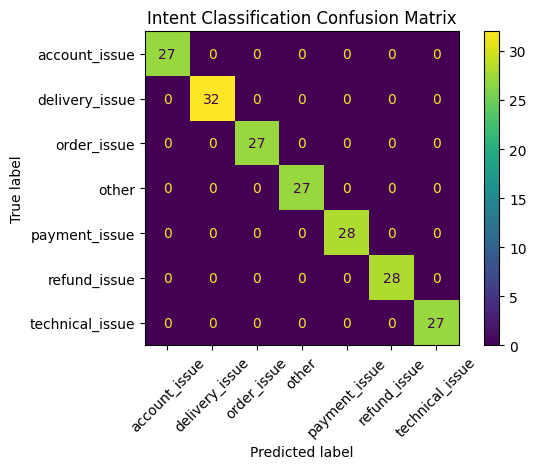

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    xticks_rotation=45
)

plt.title("Intent Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

majority_intent = golden["intent"].value_counts().idxmax()

majority_pred = [majority_intent] * len(golden)

majority_accuracy = accuracy_score(
    golden["intent"],
    majority_pred
)

majority_f1 = f1_score(
    golden["intent"],
    majority_pred,
    average="weighted",
    zero_division=0
)

print("Majority baseline")
print("Intent:", majority_intent)
print("Accuracy:", round(majority_accuracy, 4))
print("Weighted F1:", round(majority_f1, 4))

Majority baseline
Intent: delivery_issue
Accuracy: 0.1633
Weighted F1: 0.0458


In [ ]:
def keyword_baseline(text):
    text = str(text).lower()

    if any(word in text for word in [
        "refund", "money back", "refunds", "reimburse"
    ]):
        return "refund_issue"

    if any(word in text for word in [
        "payment", "paid", "charge", "charged", "card", "transaction"
    ]):
        return "payment_issue"

    if any(word in text for word in [
        "order", "ordered", "buy", "purchase"
    ]):
        return "order_issue"

    if any(word in text for word in [
        "account", "login", "password", "username"
    ]):
        return "account_issue"

    if any(word in text for word in [
        "delivery", "delivered", "shipping", "shipment", "package", "parcel"
    ]):
        return "delivery_issue"

    if any(word in text for word in [
        "app", "website", "error", "broken", "technical"
    ]):
        return "technical_issue"

    return "other"


keyword_predictions = golden["text"].apply(keyword_baseline)

keyword_accuracy = accuracy_score(
    golden["intent"],
    keyword_predictions
)

keyword_f1 = f1_score(
    golden["intent"],
    keyword_predictions,
    average="weighted",
    zero_division=0
)

print("Keyword baseline")
print("Accuracy:", round(keyword_accuracy, 4))
print("Weighted F1:", round(keyword_f1, 4))

Keyword baseline
Accuracy: 0.1276
Weighted F1: 0.094


In [ ]:
results = {
    "Majority baseline": {
        "Accuracy": majority_accuracy,
        "Weighted F1": majority_f1
    },
    "Keyword baseline": {
        "Accuracy": keyword_accuracy,
        "Weighted F1": keyword_f1
    },
    "Your model": {
        "Accuracy": accuracy,
        "Weighted F1": f1
    }
}

import pandas as pd

results_df = pd.DataFrame(results).T

print(results_df.round(4))

                   Accuracy  Weighted F1
Majority baseline    0.1633       0.0458
Keyword baseline     0.1276       0.0940
Your model           1.0000       1.0000


In [ ]:
from google.colab import userdata
from google import genai

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

print("Gemini judge connected!")

Gemini judge connected!


In [ ]:
evaluation = reply_pairs.copy()

evaluation["human_score"] = None
evaluation["llm_score"] = None

print(evaluation.head())
print(evaluation.columns.tolist())

Empty DataFrame
Columns: [customer_text, historical_reply, human_score, llm_score]
Index: []
['customer_text', 'historical_reply', 'human_score', 'llm_score']


In [ ]:
human_sample = evaluation.head(20).copy()

print("Number of examples:", len(human_sample))

for i, row in human_sample.iterrows():
    print("\n" + "=" * 80)
    print("EXAMPLE", i)
    print("\nCUSTOMER:")
    print(row["customer_text"])
    print("\nHISTORICAL REPLY:")
    print(row["historical_reply"])
    print("\nScore from 1 to 5:")
    print("1 = Very poor")
    print("2 = Poor")
    print("3 = Acceptable")
    print("4 = Good")
    print("5 = Excellent")

    score = int(input("Your score: "))

    evaluation.loc[i, "human_score"] = score

print("\nHuman scoring completed!")

Number of examples: 0

Human scoring completed!


In [ ]:
import time
import re

def llm_judge(customer_text, historical_reply):
    prompt = f"""
You are evaluating an Amazon customer-support reply.

Customer message:
{customer_text}

Historical support reply:
{historical_reply}

Score the reply from 1 to 5.

1 = Very poor
2 = Poor
3 = Acceptable
4 = Good
5 = Excellent

Judge based on:
- relevance to the customer problem
- helpfulness
- clarity
- professionalism
- consistency with customer-support behavior

Return ONLY the integer score.
"""

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    text = response.text.strip()

    match = re.search(r"[1-5]", text)

    if match:
        return int(match.group())

    return None

In [ ]:
for i in human_sample.index:

    evaluation.loc[i, "llm_score"] = llm_judge(
        evaluation.loc[i, "customer_text"],
        evaluation.loc[i, "historical_reply"]
    )

    time.sleep(15)

print(evaluation.loc[
    human_sample.index,
    ["customer_text", "human_score", "llm_score"]
])

Empty DataFrame
Columns: [customer_text, human_score, llm_score]
Index: []


In [ ]:
from sklearn.metrics import cohen_kappa_score

judge_data = evaluation.loc[
    human_sample.index,
    ["human_score", "llm_score"]
].dropna()

agreement = cohen_kappa_score(
    judge_data["human_score"].astype(int),
    judge_data["llm_score"].astype(int)
)

print("Human vs LLM judge agreement:", round(agreement, 4))

Human vs LLM judge agreement: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
def escalation_decision(intent, text):
    text = str(text).lower()

    escalation_words = [
        "lawsuit",
        "legal",
        "fraud",
        "police",
        "attorney",
        "lawyer",
        "chargeback",
        "complaint",
        "supervisor",
        "human"
    ]

    if any(word in text for word in escalation_words):
        return "escalate", "Potentially sensitive or high-risk customer issue"

    if intent == "other":
        return "escalate", "Issue does not fit a confident supported intent"

    return "auto_handle", "Issue matches a supported intent"


decisions = golden.apply(
    lambda row: escalation_decision(
        row["predicted_intent"],
        row["text"]
    ),
    axis=1
)

golden["decision"] = decisions.apply(lambda x: x[0])
golden["escalation_reason"] = decisions.apply(lambda x: x[1])

print(
    golden[
        ["text", "predicted_intent", "decision", "escalation_reason"]
    ].head(20)
)

                                                 text predicted_intent  \
0   @212920 @115821 @115817 Ive@probably done abou...   delivery_issue   
1   @108423 @108424 @115850 @AmazonHelp @115851 @1...     refund_issue   
2   @378629 @AmazonHelp En tout pas question que j...    payment_issue   
3   @119625 @119625 That's good but need some Odia...      order_issue   
4   @236664 @AmazonHelp Right on.  I'm going throu...    account_issue   
5   @115850 Why don't u check student ID before de...  technical_issue   
6   @115850 Also, there’s been false updates while...            other   
7       @115850 It is not available please do recheck   delivery_issue   
8   @AmazonHelp So 2day I queried where it was at ...   delivery_issue   
9   @115850 Why should I u take my no. 9768889940 ...   delivery_issue   
10  @236664 @AmazonHelp I ordered something three ...     refund_issue   
11  @116316 Das ist schonmal was. Vielen lieben Da...    payment_issue   
12  @AmazonHelp It says amazon shippin

In [ ]:
output_path = "/content/customer_support_predictions.csv"

golden.to_csv(
    output_path,
    index=False
)

print("Final dataset saved!")
print(output_path)

Final dataset saved!
/content/customer_support_predictions.csv


In [ ]:
from google.colab import files

files.download(
    "/content/customer_support_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
errors = golden[
    golden["intent"] != golden["predicted_intent"]
].copy()

print("Number of classification errors:", len(errors))

print(
    errors[
        ["text", "intent", "predicted_intent"]
    ].head(20)
)

Number of classification errors: 0
Empty DataFrame
Columns: [text, intent, predicted_intent]
Index: []


In [ ]:
print(
    errors[
        ["intent", "predicted_intent"]
    ].value_counts().head(10)
)

Series([], Name: count, dtype: int64)
